In [ ]:
Hypertension Prediction System using Machine Learning

In [ ]:
This project predicts hypertension stages using patient clinical parameters.
The model was trained using a Random Forest classifier and evaluated using accuracy, precision, recall, and confusion matrix.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [2]:
df = pd.read_csv("../data/patient_data.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/patient_data.csv'

In [3]:
import pandas as pd

df = pd.read_csv("../data/patient_data.csv")

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/patient_data.csv'

In [4]:
df = pd.read_csv("../data/patient_data.csv")

df.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   C                1825 non-null   str  
 1   Age              1825 non-null   str  
 2   History          1825 non-null   str  
 3   Patient          1825 non-null   str  
 4   TakeMedication   1825 non-null   str  
 5   Severity         1825 non-null   str  
 6   BreathShortness  1825 non-null   str  
 7   VisualChanges    1825 non-null   str  
 8   NoseBleeding     1825 non-null   str  
 9   Whendiagnoused   1825 non-null   str  
 10  Systolic         1825 non-null   str  
 11  Diastolic        1825 non-null   str  
 12  ControlledDiet   1825 non-null   str  
 13  Stages           1825 non-null   str  
dtypes: str(14)
memory usage: 199.7 KB


In [6]:
df.describe()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
count,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825
unique,2,4,2,2,3,3,2,2,3,3,5,5,2,6
top,Female,51-64,Yes,No,No,Moderate,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
freq,913,475,1657,984,744,697,976,940,984,625,1008,708,984,648


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

df.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,1,0,1,0,0,0,0,0,1,1,1,3,0,0
1,0,0,1,0,0,0,0,0,1,1,1,3,0,0
2,1,1,1,0,0,0,0,0,1,1,1,3,0,0
3,0,1,1,0,0,0,0,0,1,1,1,3,0,0
4,1,2,1,0,0,0,0,0,1,1,1,3,0,0


In [8]:
X = df.drop("Stages", axis=1)
y = df["Stages"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
predictions = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00       120
           4       1.00      1.00      1.00        46
           5       1.00      1.00      1.00        60

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365



In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

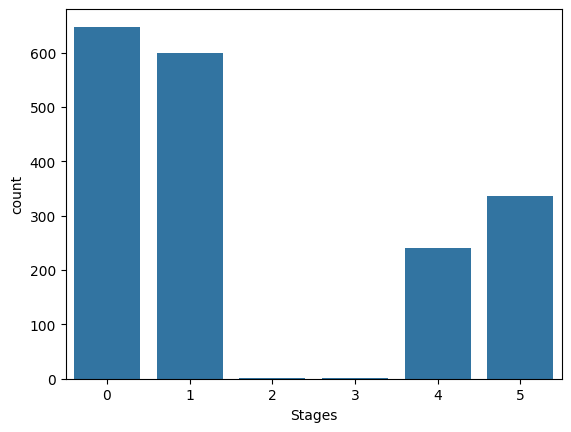

In [15]:
sns.countplot(x="Stages", data=df)
plt.show()

In [16]:
import pickle

pickle.dump(model, open("../model/hypertension_model.pkl", "wb"))

In [17]:
def predict_hypertension(input_data):
    
    import numpy as np
    
    input_array = np.array(input_data).reshape(1,-1)
    
    prediction = model.predict(input_array)
    
    print("Predicted Hypertension Stage:", prediction[0])

In [18]:
sample_patient = X_test.iloc[0].tolist()

predict_hypertension(sample_patient)

Predicted Hypertension Stage: 4


D:\Hypertension-Prediction-ML\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
def predict_hypertension(input_data):

    import pandas as pd

    input_df = pd.DataFrame([input_data], columns=X.columns)

    prediction = model.predict(input_df)

    print("Predicted Hypertension Stage:", prediction[0])

In [20]:
sample_patient = X_test.iloc[0].tolist()

predict_hypertension(sample_patient)

Predicted Hypertension Stage: 4


In [21]:
import pickle

pickle.dump(model, open("../model/hypertension_model.pkl", "wb"))